In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import warnings 
import seaborn as sns
warnings.filterwarnings('ignore')

In [20]:
from sklearn.preprocessing import StandardScaler, OrdinalEncoder #convert category data in number 
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import cross_val_score, KFold, train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import pickle

In [21]:
calories=pd.read_csv('calories.csv')
exercise=pd.read_csv('exercise.csv')

In [22]:
calories.head()

,User_ID,Calories
0,14733363,231.0
1,14861698,66.0
2,11179863,26.0
3,16180408,71.0
4,17771927,35.0


In [23]:
calories.columns

Index(['User_ID', 'Calories'], dtype='object')

In [24]:
calories.isnull().sum()

User_ID     0
Calories    0
dtype: int64

In [25]:
calories.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   User_ID   15000 non-null  int64  
 1   Calories  15000 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 234.5 KB


In [26]:
calories.isna()

,User_ID,Calories
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False
...,...,...
14995,False,False
14996,False,False
14997,False,False
14998,False,False


In [27]:
calories.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
14995    False
14996    False
14997    False
14998    False
14999    False
Length: 15000, dtype: bool

In [28]:
exercise.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8


In [29]:
exercise.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
dtypes: float64(5), int64(2), object(1)
memory usage: 937.6+ KB


In [30]:
data = pd.merge(calories, exercise, on = 'User_ID')

In [31]:
data.head()

,User_ID,Calories,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,231.0,male,68,190.0,94.0,29.0,105.0,40.8
1,14861698,66.0,female,20,166.0,60.0,14.0,94.0,40.3
2,11179863,26.0,male,69,179.0,79.0,5.0,88.0,38.7
3,16180408,71.0,female,34,179.0,71.0,13.0,100.0,40.5
4,17771927,35.0,female,27,154.0,58.0,10.0,81.0,39.8


In [32]:
data.shape

(15000, 9)

In [33]:
data.describe()

,User_ID,Calories,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,89.539533,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453
std,2.872851e+06,62.456978,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230
min,1.000116e+07,1.000000,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000
25%,1.247419e+07,35.000000,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000
50%,1.499728e+07,79.000000,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000
75%,1.744928e+07,138.000000,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000
max,1.999965e+07,314.000000,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000


In [34]:
data.duplicated().any()

np.False_

In [35]:
#Data Visualization

<Axes: xlabel='count', ylabel='Gender'>

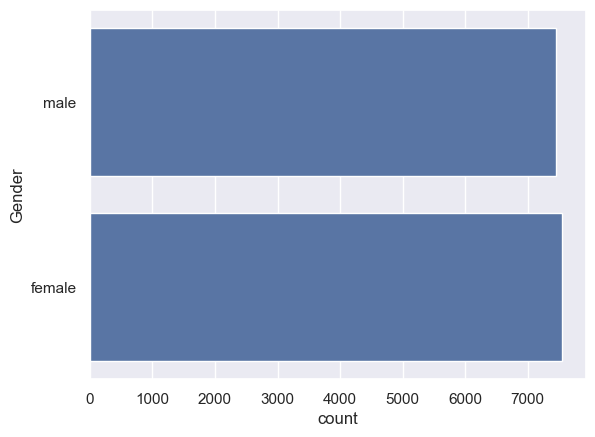

In [39]:
sns.set()
sns.countplot(data['Gender'])

<Axes: xlabel='Age', ylabel='Density'>

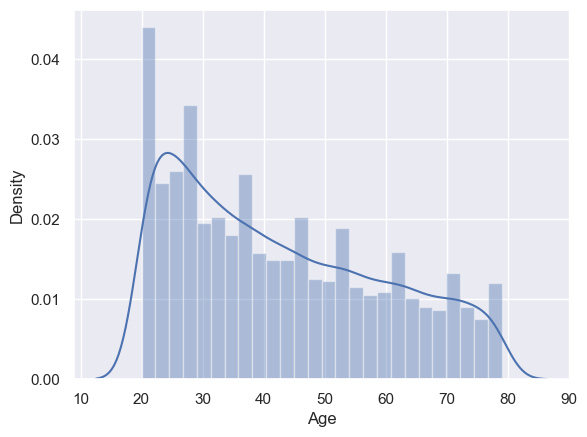

In [43]:
sns.distplot(data['Age'],kde=True)

<Axes: xlabel='Height', ylabel='Density'>

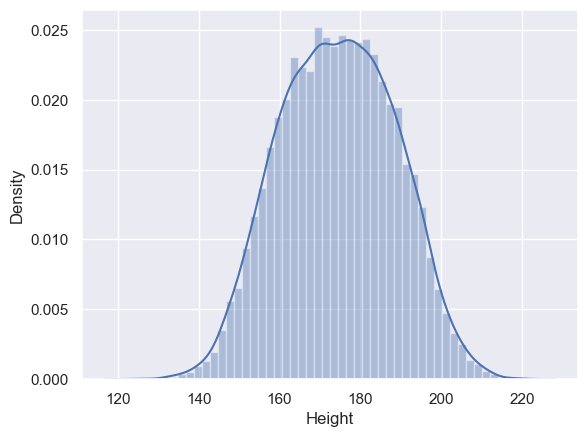

In [44]:
sns.distplot(data['Height'])

<Axes: xlabel='Weight', ylabel='Density'>

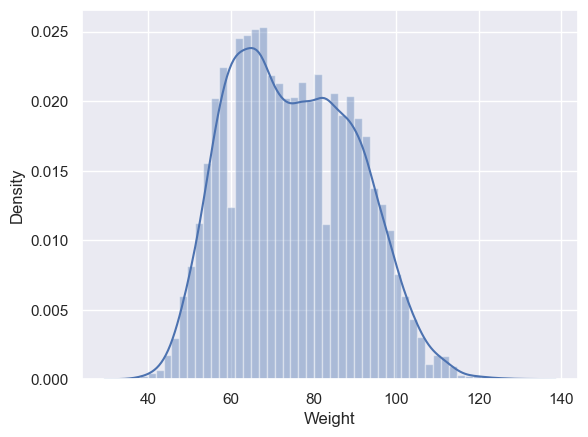

In [45]:
sns.distplot(data['Weight'])

In [55]:
data.head()

,User_ID,Calories,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,231.0,0,68,190.0,94.0,29.0,105.0,40.8
1,14861698,66.0,1,20,166.0,60.0,14.0,94.0,40.3
2,11179863,26.0,0,69,179.0,79.0,5.0,88.0,38.7
3,16180408,71.0,1,34,179.0,71.0,13.0,100.0,40.5
4,17771927,35.0,1,27,154.0,58.0,10.0,81.0,39.8


In [50]:
data['Gender'] = data['Gender'].map({'male':0, 'female':1})

In [52]:
correlation=data.corr()
correlation

,User_ID,Calories,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
User_ID,1.000000,-0.001661,0.000687,-0.001827,-0.013520,-0.011603,-0.002751,-0.000457,0.000923
Calories,-0.001661,1.000000,-0.022357,0.154395,0.017537,0.035481,0.955421,0.897882,0.824558
Gender,0.000687,-0.022357,1.000000,-0.003222,-0.710534,-0.783186,-0.003440,-0.011555,-0.007264
Age,-0.001827,0.154395,-0.003222,1.000000,0.009554,0.090094,0.013247,0.010482,0.013175
Height,-0.013520,0.017537,-0.710534,0.009554,1.000000,0.958451,-0.004625,0.000528,0.001200
Weight,-0.011603,0.035481,-0.783186,0.090094,0.958451,1.000000,-0.001884,0.004311,0.004095
Duration,-0.002751,0.955421,-0.003440,0.013247,-0.004625,-0.001884,1.000000,0.852869,0.903167
Heart_Rate,-0.000457,0.897882,-0.011555,0.010482,0.000528,0.004311,0.852869,1.000000,0.771529
Body_Temp,0.000923,0.824558,-0.007264,0.013175,0.001200,0.004095,0.903167,0.771529,1.000000


In [53]:
plt.figure(figsize=(20,10))

<Figure size 2000x1000 with 0 Axes>

<Figure size 2000x1000 with 0 Axes>

<Axes: >

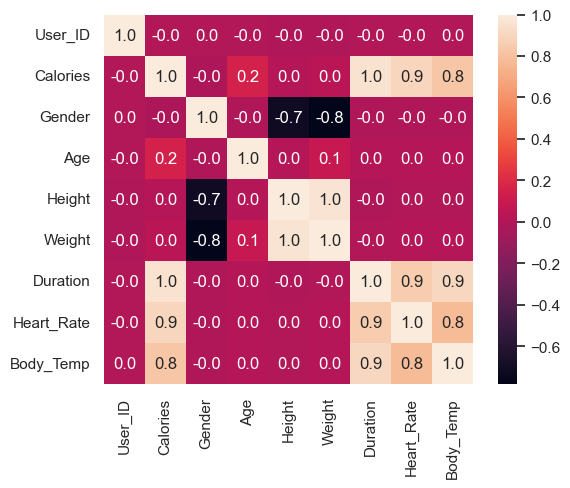

In [57]:
sns.heatmap(correlation, cbar = True, square=True, fmt = ".1f", annot=True)

In [58]:
data.columns

Index(['User_ID', 'Calories', 'Gender', 'Age', 'Height', 'Weight', 'Duration',
       'Heart_Rate', 'Body_Temp'],
      dtype='object')

In [59]:
X=data.drop(columns=['User_ID','Calories'])
y=data['Calories']

In [60]:
y

0        231.0
1         66.0
2         26.0
3         71.0
4         35.0
         ...  
14995     45.0
14996     23.0
14997     75.0
14998     11.0
14999     98.0
Name: Calories, Length: 15000, dtype: float64

In [83]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [84]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), ['Age', 'Height', 'Gender','Weight', 'Duration','Heart_Rate', 'Body_Temp'])
], remainder='passthrough')

In [85]:
#XGBRegressor
pipeline_XGBRegressor = Pipeline([
    ('preprocessor', preprocessor), 
    ('model', XGBRegressor())]
)

In [86]:
pipeline_XGBRegressor.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [87]:
y_pred = pipeline_XGBRegressor.predict(X_test)

In [88]:
r2_score(y_test, y_pred)

0.9988677544140592

In [89]:
mean_absolute_error(y_test, y_pred)

1.4985663214921952

In [90]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_val_score(pipeline, X, y, cv = kfold, scoring = 'r2')

In [91]:
cv_results.mean()

np.float64(0.9979293488027924)

In [92]:
#RandomForest
pipeline_Forest = Pipeline([
    ('preprocessor', preprocessor), 
    ('model', RandomForestRegressor())]
)

In [93]:
pipeline_Forest.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [94]:
y_predForest = pipeline_Forest.predict(X_test)

In [95]:
r2_score(y_test, y_predForest)

0.9982459634812424

In [96]:
mean_absolute_error(y_test, y_predForest)

1.7054033333333336

In [97]:
#LinearRegression
pipeline_LinearRegression = Pipeline([
    ('preprocessor', preprocessor), 
    ('model', LinearRegression())]
)

In [103]:
pipeline_LinearRegression.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [104]:
y_predLinearRegression=pipeline_LinearRegression.predict(X_test)

In [100]:
r2_score(y_test, y_predLinearRegression)

0.9672937151257295

In [102]:
mean_absolute_error(y_test, y_predLinearRegression)

8.441513553849704

In [105]:
#Export Model XGBRegressor
with open('pipeline_model.pkl', 'wb') as f:
    pickle.dump(pipeline_XGBRegressor, f)